## AI, Global grid and energy for the future
### SOUND.AI training session, 3rd of April 2026

This code was prepared by Nina Drobac. The open-source data used is provided by Météo France and RTE and was compiled and merged by Margaux Brégère. 

In [676]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pygam import LinearGAM, s, f

#### 📑 Dataset load & variable description

This dataset contains half-hourly electricity demand observations along with calendar and weather-related features. The data is aggregated on the national level of France. The observations span years 2013 to 2022, resulting in 175295 data points.

* **`timestamp`**: Date and time of the observation (30-minute intervals).
* **`load`**: Electricity demand (target variable to forecast), measured in megawatts (MW).
* **`halfhour`**: Index of the half-hour period within the day (0–47).
* **`dow`**: Day of the week.
* **`is_holiday`**: Boolean indicator specifying whether the day is a public holiday.
* **`is_dayoff`**: Boolean indicator for non-working days.
* **`year_position`**: Continuous variable (0 to 1) indicating the position within the year.
* **`is_summer_time`**: Boolean indicator for daylight saving time (DST).
* **`temperature`**: Air temperature (°C).
* **`nebulosity`**: Cloud coverage (%).
* **`humidity`**: Relative humidity (%), reflecting moisture in the air.
* **`pressure`**: Atmospheric pressure (Pa).
* **`pressure_variation`**: Change in atmospheric pressure.
* **`wind_direction`**: Wind direction (degrees), describing the origin of wind flow.
* **`wind_speed`**: Wind speed.
* **`temperature_dew`**: Dew point temperature (°C), indicating the level of moisture in the air.

In [677]:
base_dir = Path.cwd()
file_path = base_dir / "data.csv"
df = pd.read_csv(file_path, decimal=".")
df['timestamp'] = pd.to_datetime(df['timestamp'])
# print(df.head())

### 📊 Descriptive Analysis
#### 📅 1. Calendar variables
Calendar variables are useful for explaining the seasonality in the data. We can observe this seasonality on three levels: daily, weekly and monthly seasonality. 
##### 🕓 Daily seasonality (explained by half hour)
Can you identify "rush hours" for electricity demand?

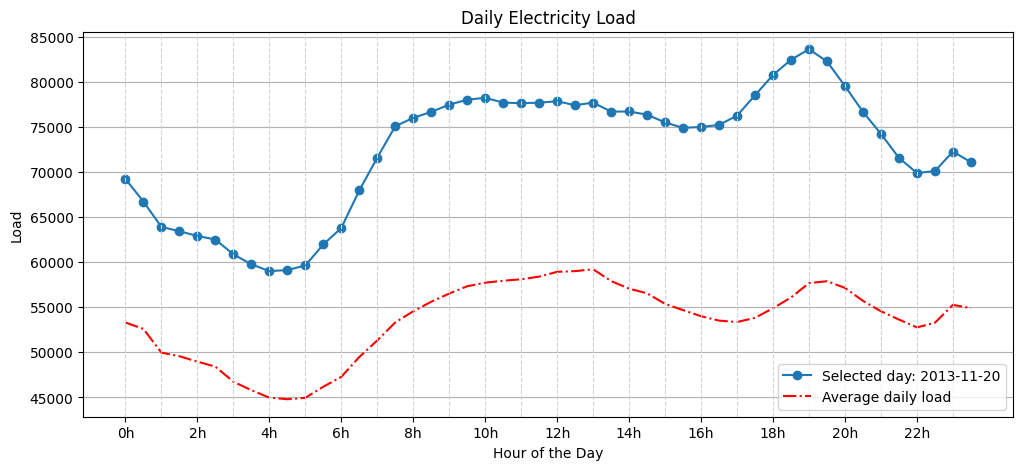

In [678]:
random_day = pd.to_datetime("2013-11-20").date()
df_day = df[df['timestamp'].dt.date == random_day].copy()
daily_avg = df.groupby('halfhour')['load'].mean()

plt.figure(figsize=(12,5))
plt.plot(df_day['halfhour'], df_day['load'], marker='o', label=f"Selected day: {random_day}")
plt.plot(daily_avg.index, daily_avg.values, color='red', linestyle='dashdot', label='Average daily load')

plt.xticks(ticks=np.arange(0,48,4), labels=[f"{h}h" for h in range(0,24,2)])
plt.xlabel("Hour of the Day")
plt.ylabel("Load")
plt.title("Daily Electricity Load")
plt.legend()

for h in range(0,48,2):
    plt.axvline(h, color='lightgray', linewidth=0.8, linestyle='--')
plt.grid(axis='y') 

plt.show()

##### 🕓 Weakly seasonality 
Remark that the electricity consumption is lower on weekends compared to weekdays. 

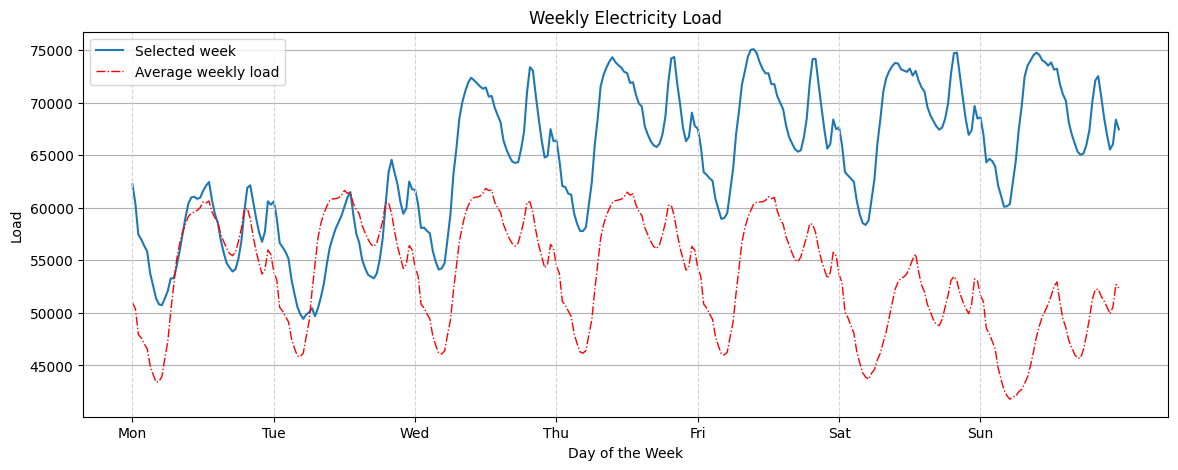

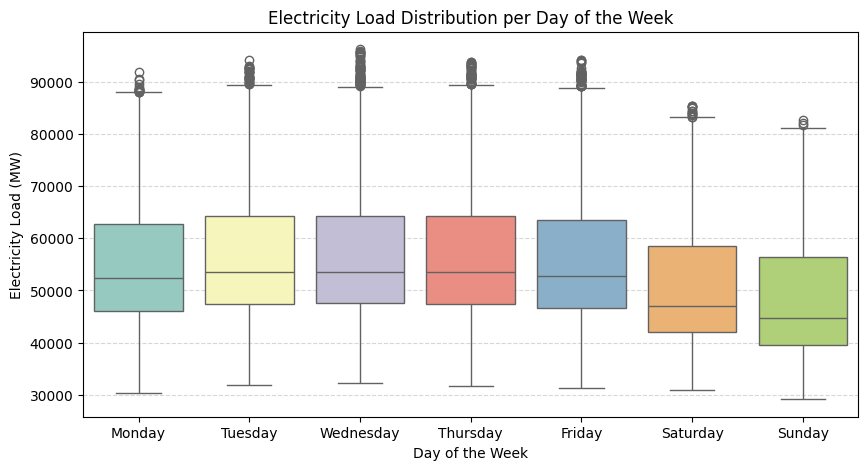

In [679]:
start_date = pd.to_datetime("2013-03-23")
end_date = pd.to_datetime("2013-03-29 23:59:59")
df_week = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)].copy()

df_week = df_week.sort_values('timestamp').reset_index(drop=True)
df['weekday'] = df['timestamp'].dt.day_name()
df_week['weekday'] = df_week['timestamp'].dt.day_name()
df_week['time_index'] = np.arange(len(df_week))

weekly_pattern = df.groupby(['weekday', 'halfhour'])['load'].mean()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_curve = []
for day in weekday_order:
    avg_curve.extend(weekly_pattern.loc[day].values)
avg_curve = np.array(avg_curve)


plt.figure(figsize=(14,5))

plt.plot(df_week['time_index'], df_week['load'], label="Selected week")

plt.plot(range(len(avg_curve)), avg_curve, color='red', linestyle='dashdot', linewidth=1, label="Average weekly load")

ticks = np.arange(0, 7*48, 48)
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.xticks(ticks=ticks, labels=labels)

plt.xlabel("Day of the Week")
plt.ylabel("Load")
plt.title("Weekly Electricity Load")
plt.legend()

for t in ticks:
    plt.axvline(t, color='lightgray', linestyle='--', linewidth=0.8)
plt.grid(axis='y')

plt.show()


# Boxplot of electricity consumption per weekday

df['weekday'] = pd.Categorical(df['weekday'], categories=weekday_order, ordered=True)
plt.figure(figsize=(10,5))
sns.boxplot(x='weekday', y='load', data=df, palette='Set3', hue='weekday', legend=False, )
plt.xlabel("Day of the Week")
plt.ylabel("Electricity Load (MW)")
plt.title("Electricity Load Distribution per Day of the Week")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

##### 📝 TO DO
Plot electricity consumption for year 2016. What do you notice, which part of the year corresponds to higher consumption? Why? 

##### 🔧 Solution
Notice the difference for warm and cold months.

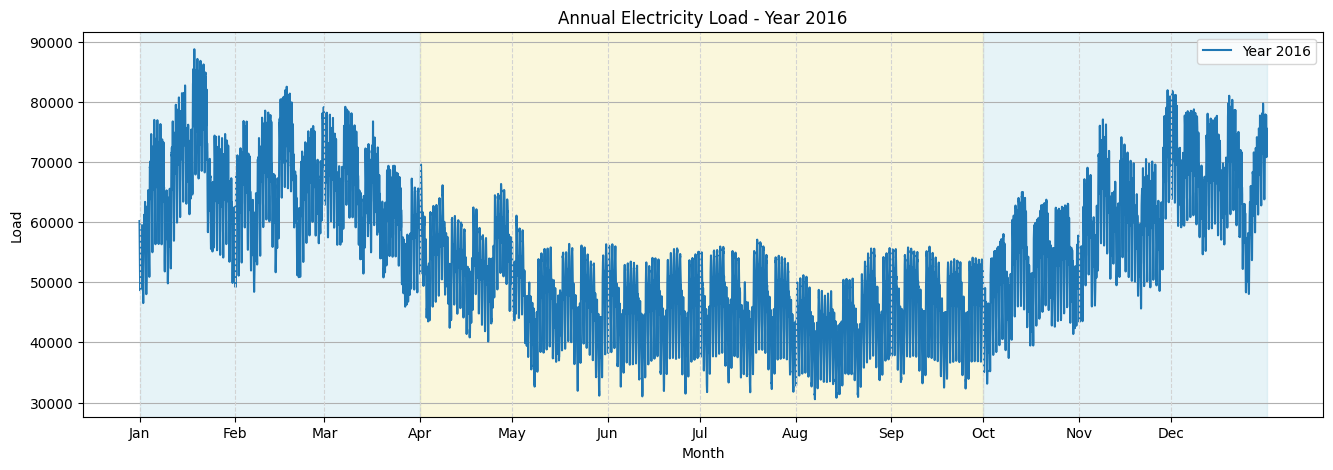

In [680]:
start_date = pd.to_datetime("2016-01-01")
end_date = pd.to_datetime("2017-01-01") 

df_year = df[(df['timestamp'] >= start_date) & (df['timestamp'] < end_date)].copy()
df_year = df_year.sort_values('timestamp').reset_index(drop=True)
df_year['time_index'] = np.arange(len(df_year))


plt.figure(figsize=(16,5))

plt.plot(df_year['time_index'], df_year['load'], label="Year 2016")

month_starts = pd.date_range("2016-01-01", "2016-12-01", freq="MS")
ticks = [(d - pd.Timestamp("2016-01-01")).days * 48 for d in month_starts]
labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.xticks(ticks=ticks, labels=labels)

plt.axvspan(ticks[0], ticks[3], color='lightblue', alpha=0.3)
plt.axvspan(ticks[3], ticks[9], color='khaki', alpha=0.3)
end_of_year = len(df_year)
plt.axvspan(ticks[9], end_of_year, color='lightblue', alpha=0.3)

plt.xlabel("Month")
plt.ylabel("Load")
plt.title("Annual Electricity Load - Year 2016")
plt.legend()

for t in ticks:
    plt.axvline(t, color='lightgray', linestyle='--', linewidth=0.8)
plt.grid(axis='y')

plt.show()

#### ☀️❄️ 2. Weather Variables

##### Descriptive analysis: correlation matrix 
Among the weather variables considered, we see that temperature has the highest absolute correlation with electricity load. In the annual analysis above, we could also identify warm and cold periods of the year which exhibit different electricity consumption patters. We will therefore focus on the impact of temperature on load.

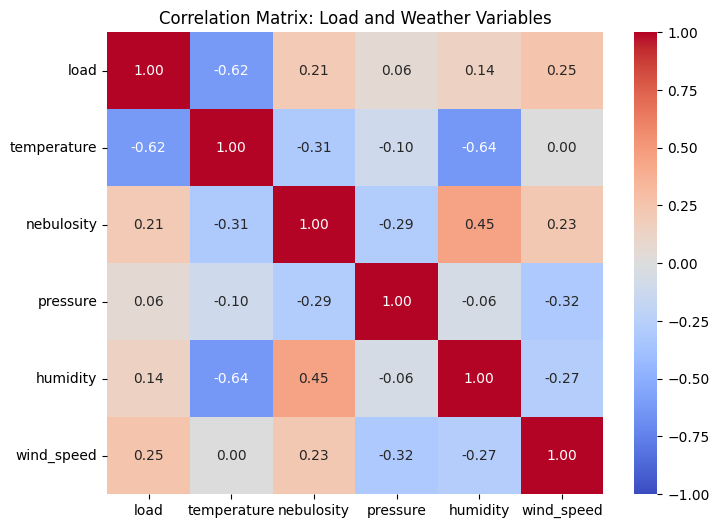

In [681]:
weather_vars = ['temperature', 'nebulosity', 'pressure', 'humidity', 'wind_speed']
corr_df = df[['load'] + weather_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix: Load and Weather Variables")
plt.show()

##### 🌡️ Temperature 
Temperature fluctuations strongly influence electricity load patterns, mostly due to heating in winter and cooling in summer. We observe a **quadratic** relationship between consumption and temperature: when temperature is low, the consumption is high due to heating, as outside temperature grows the consumption drops, and once the outside temperature rises above 25 degrees, the electricity consumption increases again due to cooling. 

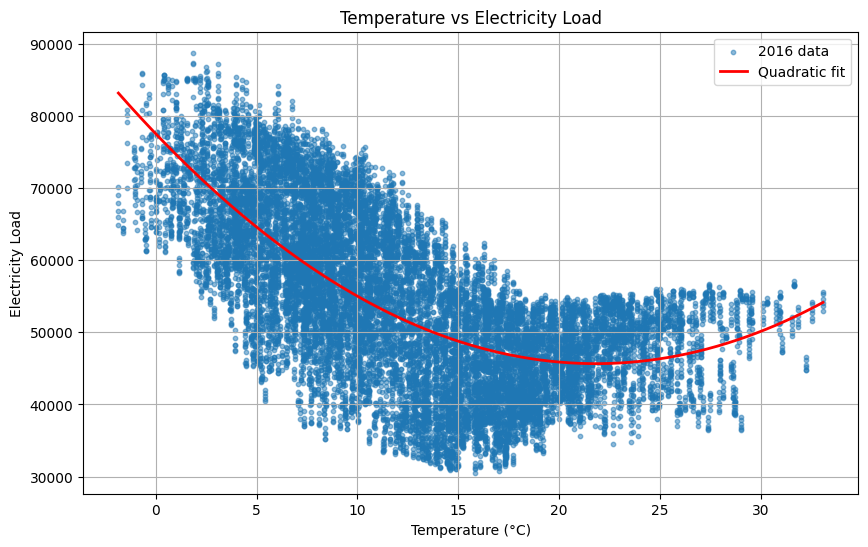

In [682]:
year = 2016
start_date = pd.to_datetime(f"{year}-01-01")
end_date = pd.to_datetime(f"{year+1}-01-01")
df_year = df[(df['timestamp'] >= start_date) & (df['timestamp'] < end_date)].copy()

x = df_year['temperature'].values  
y = df_year['load'].values        

# Fit quadratic curve
coeffs = np.polyfit(x, y, 2) 
quad_fit = np.poly1d(coeffs)
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = quad_fit(x_fit)

plt.figure(figsize=(10,6))
plt.scatter(x, y, s=10, alpha=0.5, label=f"{year} data")
plt.plot(x_fit, y_fit, color='red', linewidth=2, label="Quadratic fit")

plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Load")
plt.title("Temperature vs Electricity Load")
plt.legend()
plt.grid(True)
plt.show()

##### 📉 Delay in the effect of covariates
A phenomenon important for modeling the impact of temperature on electricity load is the **thermal inertia of buildings**. While outside temperatures can fluctuate rapidly, these changes are less pronounced inside buildings. Additionally, a drop or rise in outside temperature takes time to be reflected indoors. This delay means it’s important to account for **lagged effects** of temperature on electricity consumption, as well as to smooth short-term fluctuations in outdoor temperature. One effective way to model this is by using **exponentially smoothed temperature** rather than the raw temperature itself. The smoothing parameter controls the strength of the smoothing, see TO DO.

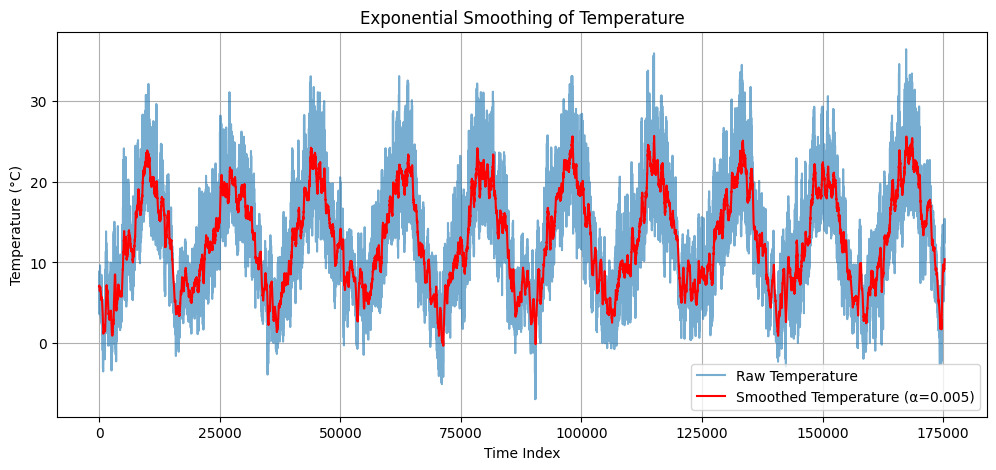

In [683]:
def exp_smoothing(temp_series, alpha=0.005):
    smoothed = np.zeros_like(temp_series)
    smoothed[0] = temp_series[0]
    for t in range(1, len(temp_series)):
        smoothed[t] = alpha * temp_series[t] + (1 - alpha) * smoothed[t-1]
    return smoothed

smoothing_param = 0.005     # TO DO: change this to other values: 0.1, 0.01, 0.001, etc. What do you observe?
temp = df["temperature"].values
temp_smoothed = exp_smoothing(temp, alpha=smoothing_param)

plt.figure(figsize=(12,5))
plt.plot(temp, label="Raw Temperature", alpha=0.6)
plt.plot(temp_smoothed, label=f"Smoothed Temperature (α={smoothing_param})", color='red')
plt.xlabel("Time Index")
plt.ylabel("Temperature (°C)")
plt.title("Exponential Smoothing of Temperature")
plt.legend()
plt.grid(True)
plt.show()

## ⚡ Simple Model for Electricity Load Forecasting

We can now build a **simple baseline model** for forecasting electricity load by leveraging our previous observation of the **quadratic relationship** between load and temperature, as well as the **lag** in this effect.
A straightforward approach is to use a **linear regression model** that takes the **exponentially smoothed temperature** and its **square** as input features.  

**Train-test split**:
- **Training set:** Years 2013–2016
- **Test set:** Years 2017–2019

**Procedure:**
1. Prepare the features: `temp_smoothed` and `temp_smoothed²`.
2. Split the dataset into train and test sets based on the year.
3. Fit a **linear regression model** on the training data.
4. Make predictions on both training and test sets.
5. Plot the actual vs predicted load for both train and test periods.
6. Compute error metrics to evaluate the model.

The plot allows us to visually inspect the **goodness of fit**, while the metrics quantify the **prediction accuracy** on both the training and test periods.

**Error metrics**
To evaluate the performance of our load forecasting model, we use the following **common error metrics**. Here $y_i$ denotes the true value, and $\hat{y}_i$ the prediction.

1. **Root Mean Squared Error (RMSE)**
   - $\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2}$  
   - **Interpretation:** Measures the standard deviation of the prediction errors. Larger errors are **penalized more heavily** because of the square term. RMSE is sensitive to outliers and is expressed in the **same units as the target variable**.

2. **Mean Absolute Error (MAE)**
   - $\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |\hat{y}_i - y_i|$
   - **Interpretation:** Represents the **average absolute difference** between predicted and actual values. MAE is **less sensitive to outliers** than RMSE and is easy to interpret in the **original units**.

3. **Mean Absolute Percentage Error (MAPE)**
   - $\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{\hat{y}_i - y_i}{y_i} \right|$
   - **Interpretation:** Expresses the error as a **percentage of the actual value**, which makes it **scale-independent**. MAPE is useful for understanding relative prediction accuracy but can be unstable when the true values are close to zero.

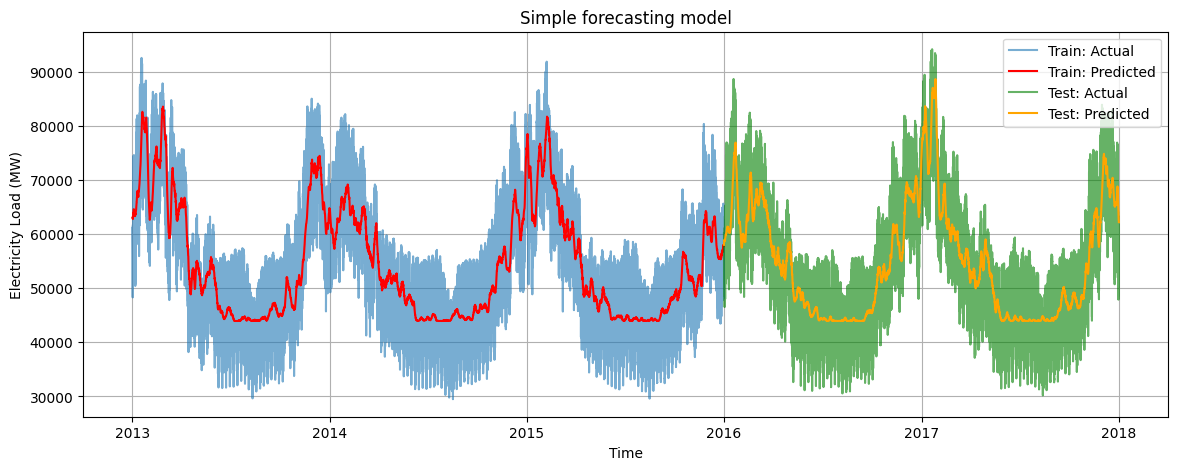

Train Metrics
RMSE: 6529.32 MW | MAE: 5464.66 MW | MAPE: 10.65 %

Test Metrics
RMSE: 6448.47 MW | MAE: 5384.07 MW | MAPE: 10.39 %


In [684]:
X = np.column_stack([temp_smoothed, temp_smoothed**2])
y = df["load"].values
df['year'] = df['timestamp'].dt.year

train_mask = (df['year'] >= 2013) & (df['year'] <= 2015)
test_mask  = (df['year'] >= 2016) & (df['year'] <= 2017)
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Fit linear regression model 
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predictions
y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

# Compute error metrics 
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return rmse, mae, mape

train_rmse, train_mae, train_mape = compute_metrics(y_train, y_train_pred)
test_rmse, test_mae, test_mape    = compute_metrics(y_test, y_test_pred)

# Plot results
plt.figure(figsize=(14,5))
plt.plot(df['timestamp'][train_mask], y_train, label="Train: Actual", alpha=0.6)
plt.plot(df['timestamp'][train_mask], y_train_pred, label="Train: Predicted", color='red')
plt.plot(df['timestamp'][test_mask], y_test, label="Test: Actual", color="green", alpha=0.6)
plt.plot(df['timestamp'][test_mask], y_test_pred, label="Test: Predicted", color='orange')
plt.xlabel("Time")
plt.ylabel("Electricity Load (MW)")
plt.title("Simple forecasting model")
plt.legend()
plt.grid(True)
plt.show()

print("Train Metrics")
print(f"RMSE: {train_rmse:.2f} MW | MAE: {train_mae:.2f} MW | MAPE: {train_mape:.2f} %\n")
print("Test Metrics")
print(f"RMSE: {test_rmse:.2f} MW | MAE: {test_mae:.2f} MW | MAPE: {test_mape:.2f} %")

**Notice:** The quadratic temperature model captures the average trend well but fails at the lower parts because it ignores day-of-week patterns, holidays, and rapid fluctuations, and because squared-error regression emphasizes fitting high-load periods.

##### 📝 TO DO
Fit a model per half-hour to account for the fact that the electricity load is lower during certain times of the day.

---

##### 🔧 Solution

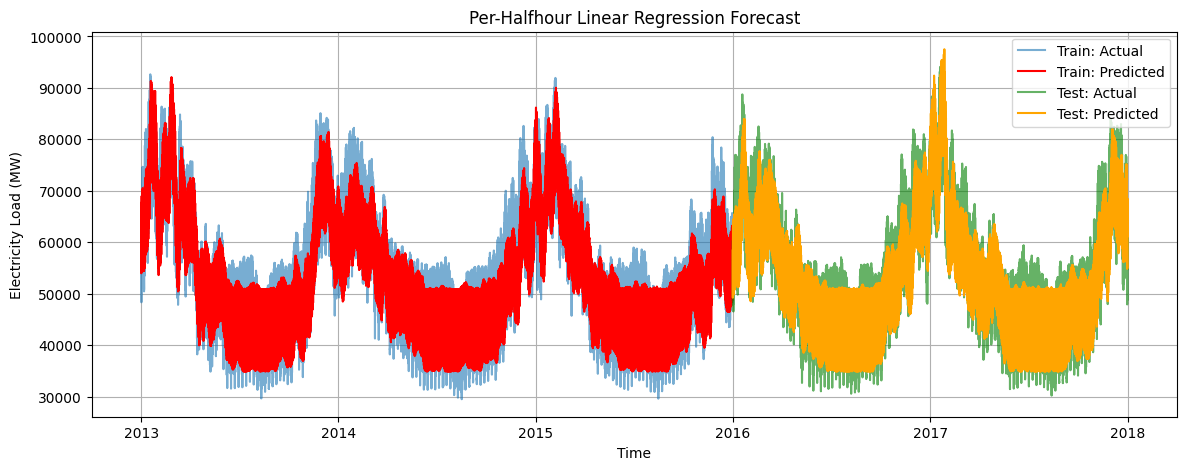

Train Metrics
RMSE: 4830.10 MW | MAE: 3805.53 MW | MAPE: 7.30 %

Test Metrics
RMSE: 4775.53 MW | MAE: 3753.73 MW | MAPE: 7.11 %


In [685]:
df['load'] = df['load'].values

X_all = np.column_stack([temp_smoothed, temp_smoothed**2])
y_all = df['load'].values

models = {}
y_train_pred = np.zeros(sum(train_mask))
y_test_pred  = np.zeros(sum(test_mask))

# Fit one model per half-hour
for hh in range(48):
    hh_mask_train = train_mask & (df['halfhour'] == hh)
    hh_mask_test  = test_mask  & (df['halfhour'] == hh)
    
    X_train = X_all[hh_mask_train]
    y_train = y_all[hh_mask_train]
    
    X_test  = X_all[hh_mask_test]
    
    # Fit linear regression per half-hour
    reg = LinearRegression()
    reg.fit(X_train, y_train)
    models[hh] = reg
    
    # Predict
    y_train_pred[hh_mask_train[train_mask]] = reg.predict(X_train)
    y_test_pred[hh_mask_test[test_mask]]   = reg.predict(X_test)

train_rmse, train_mae, train_mape = compute_metrics(y_all[train_mask], y_train_pred)
test_rmse, test_mae, test_mape    = compute_metrics(y_all[test_mask], y_test_pred)

# Plot predictions
plt.figure(figsize=(14,5))
plt.plot(df['timestamp'][train_mask], y_all[train_mask], label="Train: Actual", alpha=0.6)
plt.plot(df['timestamp'][train_mask], y_train_pred, label="Train: Predicted", color='red')
plt.plot(df['timestamp'][test_mask], y_all[test_mask], label="Test: Actual", color="green",alpha=0.6)
plt.plot(df['timestamp'][test_mask], y_test_pred, label="Test: Predicted", color='orange')
plt.xlabel("Time")
plt.ylabel("Electricity Load (MW)")
plt.title("Per-Halfhour Linear Regression Forecast")
plt.legend()
plt.grid(True)
plt.show()

# Print metrics
print("Train Metrics")
print(f"RMSE: {train_rmse:.2f} MW | MAE: {train_mae:.2f} MW | MAPE: {train_mape:.2f} %\n")
print("Test Metrics")
print(f"RMSE: {test_rmse:.2f} MW | MAE: {test_mae:.2f} MW | MAPE: {test_mape:.2f} %")

## 🎯 Generalized Additive Models (GAMs)

A **Generalized Additive Model (GAM)** is an extension of linear models that allows the relationship between the predictors and the target variable to be **non-linear and flexible**, while still maintaining **interpretability**.

Formally, a GAM expresses the expected value of the response variable $Y$ as:
$g(\mathbb{E}[Y]) = \beta_0 + f_1(X_1) + f_2(X_2) + \dots + f_p(X_p),$ where

- $g(\cdot)$ is a **link function** (identity for regression, log for Poisson, etc.)  
- $f_i(X_i)$ are **smooth functions** of the predictors.

---

### 💡 Application to Electricity Load Forecasting

In our electricity load dataset, we can use a GAM to model load as a **smooth function of temperature**, while also including **calendar and time features**:

- Predictors:
  - `temperature` → we consider the smooth spline $f(\text{temperature})$
  - `halfhour` → we consider the cyclic smooth spline of the half hour; cyclic to assure periodicity, captures intra-day seasonal pattern
  - `dow` → we consider a factor term of the day of the week; factor term is equivalent to dummy variables in linear regression; captures weekday/weekend effects
- Target: `load` (electricity demand)

For implementation details, please see https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html .

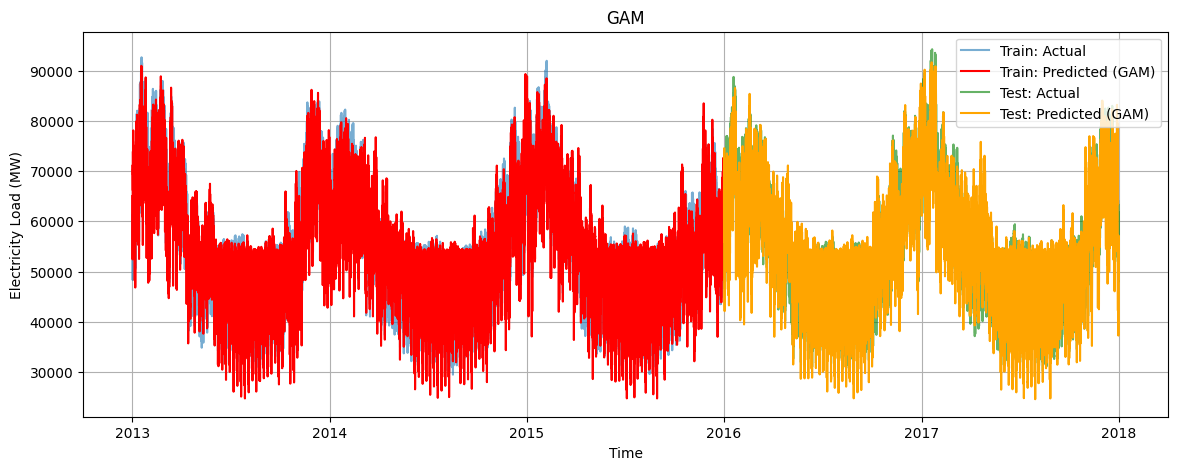

Train Metrics (GAM)
RMSE: 4266.83 MW | MAE: 3334.58 MW | MAPE: 6.47 %

Test Metrics (GAM)
RMSE: 4280.36 MW | MAE: 3313.38 MW | MAPE: 6.35 %


In [686]:
df['year'] = df['timestamp'].dt.year
X = df[['temperature', 'halfhour', 'dow']].copy()
X['dow'] = X['dow'].astype('category').cat.codes
y = df['load'].values

X_train, y_train = X.values[train_mask], y[train_mask]
X_test, y_test   = X.values[test_mask], y[test_mask]

# Fit GAM
gam = LinearGAM(s(0) + s(1,basis='cp') + f(2))
gam.fit(X_train, y_train)

# Predictions
y_train_pred = gam.predict(X_train)
y_test_pred  = gam.predict(X_test)

train_rmse, train_mae, train_mape = compute_metrics(y_train, y_train_pred)
test_rmse, test_mae, test_mape    = compute_metrics(y_test, y_test_pred)


plt.figure(figsize=(14,5))

plt.plot(df['timestamp'][train_mask], y_train,
         label="Train: Actual", alpha=0.6)

plt.plot(df['timestamp'][train_mask], y_train_pred,
         label="Train: Predicted (GAM)", color='red')

plt.plot(df['timestamp'][test_mask], y_test,
         label="Test: Actual", color="green", alpha=0.6)

plt.plot(df['timestamp'][test_mask], y_test_pred,
         label="Test: Predicted (GAM)", color='orange')

plt.xlabel("Time")
plt.ylabel("Electricity Load (MW)")
plt.title("GAM")
plt.legend()
plt.grid(True)
plt.show()


print("Train Metrics (GAM)")
print(f"RMSE: {train_rmse:.2f} MW | MAE: {train_mae:.2f} MW | MAPE: {train_mape:.2f} %\n")

print("Test Metrics (GAM)")
print(f"RMSE: {test_rmse:.2f} MW | MAE: {test_mae:.2f} MW | MAPE: {test_mape:.2f} %")

##### 📝 TO DO
 Try incorporating other explanatory variables in the GAM.

### References

Simon N. Wood; 
*Generalized Additive Models: an introduction with R*


Hastie, Tibshirani, Friedman;
*The Elements of Statistical Learning*;
http://www.stat.ucla.edu/~ywu/research/documents/BOOKS/ElementsLearningII.pdf

Antoniadis, Cugliari, Fasiolo, Goude, Poggi; *Statistical Learning Tools for Electricity Load Forecasting*
